In [1]:
# 2) Data Wrangling II
# Create an “Academic performance” dataset of students and perform the following operations using Python.

# 1.	Scan all variables for missing values and inconsistencies. If there are missing values and/or inconsistencies, use any of the suitable techniques to deal with them.
# 2.	Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques to deal with them.
# 3.	Apply data transformations on at least one of the variables. The purpose of this transformation should be one of the following reasons: to change the scale for better understanding of the variable, to convert a non-linear relation into a linear one, or to decrease the skewness and convert the distribution into a normal distribution

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Academic-Performance.csv")
df.head()

,Rollno,Name,Gender,Branch,Attendence,Phy_marks,Che_marks,EM1_marks,PPS_marks,SME_marks,Total Marks,Percentage
0,1,Mohammed,M,Comp,72.0,62.0,98.0,63.0,89.0,36.0,368,73.6
1,2,Reyansh,M,IT,58.0,62.0,83.0,83.0,88.0,34.0,350,70.0
2,3,Aarav,M,IT,57.0,-20.0,100.0,NaN,56.0,36.0,192,38.4
3,4,Atharv,M,IT,60.0,89.0,83.0,70.0,33.0,23.0,298,59.6
4,5,Vivaan,M,Comp,85.0,90.0,NaN,78.0,23.0,56.0,247,49.4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rollno       20 non-null     int64  
 1   Name         18 non-null     str    
 2   Gender       20 non-null     str    
 3   Branch       20 non-null     str    
 4   Attendence   20 non-null     float64
 5   Phy_marks    19 non-null     float64
 6   Che_marks    17 non-null     float64
 7   EM1_marks    18 non-null     float64
 8   PPS_marks    19 non-null     float64
 9   SME_marks    20 non-null     float64
 10  Total Marks  20 non-null     int64  
 11  Percentage   20 non-null     float64
dtypes: float64(7), int64(2), str(3)
memory usage: 2.2 KB


In [4]:
df.describe()

,Rollno,Attendence,Phy_marks,Che_marks,EM1_marks,PPS_marks,SME_marks,Total Marks,Percentage
count,20.00000,20.000000,19.000000,17.000000,18.000000,19.000000,20.000000,20.000000,20.000000
mean,10.50000,75.100000,63.421053,80.764706,83.444444,60.736842,62.700000,327.150000,65.430000
std,5.91608,14.660724,34.940133,13.690916,11.078449,43.598983,24.891554,78.951867,15.790373
min,1.00000,53.000000,-34.000000,51.000000,63.000000,-99.000000,23.000000,192.000000,38.400000
25%,5.75000,63.750000,59.000000,70.000000,75.750000,56.000000,42.750000,279.750000,55.950000
50%,10.50000,73.000000,67.000000,83.000000,83.000000,66.000000,60.500000,338.000000,67.600000
75%,15.25000,87.000000,88.000000,93.000000,93.000000,87.500000,80.250000,381.500000,76.300000
max,20.00000,98.000000,99.000000,100.000000,100.000000,99.000000,99.000000,439.000000,87.800000


In [5]:
print(df.isnull().sum())

Rollno         0
Name           2
Gender         0
Branch         0
Attendence     0
Phy_marks      1
Che_marks      3
EM1_marks      2
PPS_marks      1
SME_marks      0
Total Marks    0
Percentage     0
dtype: int64


In [6]:
# Fill missing values in numerical columns

df['Phy_marks']=df['Phy_marks'].fillna(df['Phy_marks'].mean())

df['Che_marks']=df['Che_marks'].fillna(df['Che_marks'].mean())

df['EM1_marks']=df['EM1_marks'].fillna(df['EM1_marks'].mean())

df['PPS_marks']=df['PPS_marks'].fillna(df['PPS_marks'].mean())

In [7]:
# Fill missing values in Name
df['Name']=df['Name'].fillna('Missing')

In [8]:
df.isnull().sum()

Rollno         0
Name           0
Gender         0
Branch         0
Attendence     0
Phy_marks      0
Che_marks      0
EM1_marks      0
PPS_marks      0
SME_marks      0
Total Marks    0
Percentage     0
dtype: int64

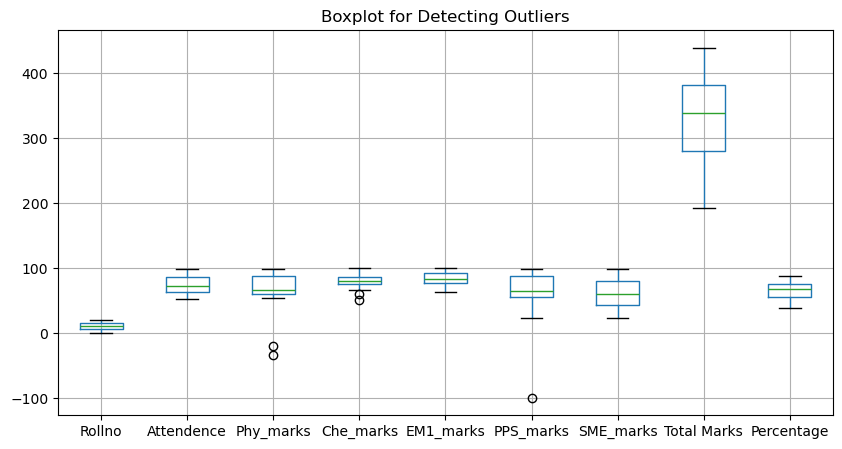

In [9]:
df.boxplot(figsize=(10,5))
plt.title("Boxplot for Detecting Outliers")

plt.show()

In [10]:
# Detect and remove outliers from PPS_marks

Q1 = df['PPS_marks'].quantile(0.25)

Q3 = df['PPS_marks'].quantile(0.75)

IQR = Q3 - Q1

# Calculate limits

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

# Remove outliers

df = df[(df['PPS_marks'] >= lower_limit) & (df['PPS_marks'] <= upper_limit)]

print(df.shape)

(19, 12)


In [11]:
# List of numerical columns

columns = ['Phy_marks', 'Che_marks', 'PPS_marks']

# Remove outliers using IQR method

for col in columns:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

# Display final shape

print(df.shape)

(10, 12)


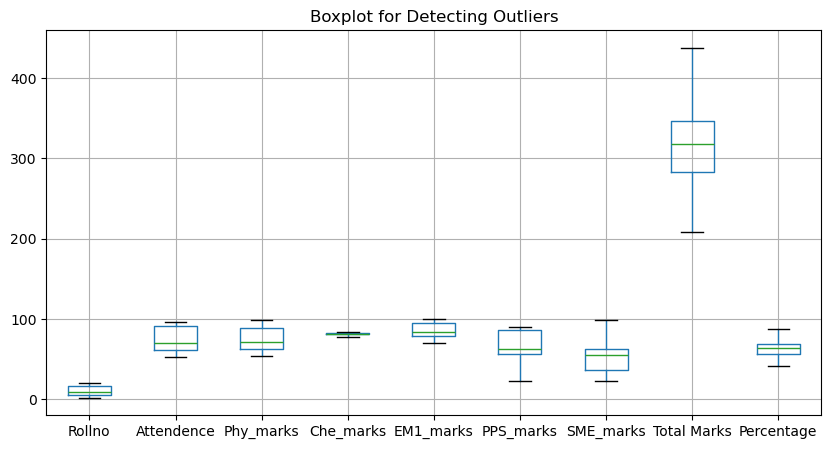

In [12]:
df.boxplot(figsize=(10,5))
plt.title("Boxplot for Detecting Outliers")

plt.show()

In [13]:
# Normalize Percentage column

df['Percentage_Normalized'] = (df['Percentage'] - df['Percentage'].min()) / (df['Percentage'].max() - df['Percentage'].min())

# Display normalized values

print(df[['Percentage', 'Percentage_Normalized']].head())

   Percentage  Percentage_Normalized
1        70.0               0.617391
3        59.6               0.391304
4        49.4               0.169565
5        87.6               1.000000
8        41.6               0.000000
